In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_data = pd.read_excel("Bird_Monitoring_Data_FOREST.XLSX", sheet_name=None, engine='openpyxl')
print(excel_data.keys())

dict_keys(['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR'])


In [3]:
combined_df = pd.concat(excel_data.values(), ignore_index=True)

In [4]:
combined_df.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,83803,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,90935,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,84865,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,93634,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,88394,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


In [5]:
combined_df.shape

(8546, 29)

In [6]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8546 entries, 0 to 8545
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              8546 non-null   object        
 1   Sub_Unit_Code                722 non-null    object        
 2   Site_Name                    8546 non-null   object        
 3   Plot_Name                    8546 non-null   object        
 4   Location_Type                8546 non-null   object        
 5   Year                         8546 non-null   int64         
 6   Date                         8546 non-null   datetime64[ns]
 7   Start_Time                   8546 non-null   object        
 8   End_Time                     8546 non-null   object        
 9   Observer                     8546 non-null   object        
 10  Visit                        8546 non-null   int64         
 11  Interval_Length              8546 non-null 

In [7]:
combined_df.isnull().sum()

Admin_Unit_Code                   0
Sub_Unit_Code                  7824
Site_Name                         0
Plot_Name                         0
Location_Type                     0
Year                              0
Date                              0
Start_Time                        0
End_Time                          0
Observer                          0
Visit                             0
Interval_Length                   0
ID_Method                         1
Distance                         92
Flyover_Observed                  0
Sex                            5183
Common_Name                       0
Scientific_Name                   0
AcceptedTSN                       9
NPSTaxonCode                      0
AOU_Code                          0
PIF_Watchlist_Status              0
Regional_Stewardship_Status       0
Temperature                       0
Humidity                          0
Sky                               0
Wind                              0
Disturbance                 

In [8]:
combined_df.drop(columns=['Sub_Unit_Code'], inplace=True)

In [9]:
combined_df['ID_Method'].fillna('Singing', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_21472\3865225957.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['ID_Method'].fillna('Singing', inplace=True)


In [10]:
mode_value = combined_df['Distance'].mode()[0]
combined_df['Distance'].fillna(mode_value, inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_21472\70422843.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['Distance'].fillna(mode_value, inplace=True)


In [11]:
combined_df['AcceptedTSN'].fillna('NULL', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_21472\1537270811.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['AcceptedTSN'].fillna('NULL', inplace=True)
C:\Users\varsh\AppData\Local\Temp\ipykernel_21472\1537270811.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'NULL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  combined_df['AcceptedTSN'].fillna('NULL', inplace=True)


In [12]:
combined_df['Sex'].fillna('Undetermined', inplace=True)

C:\Users\varsh\AppData\Local\Temp\ipykernel_21472\307641280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  combined_df['Sex'].fillna('Undetermined', inplace=True)


In [13]:
combined_df['Temperature'] = combined_df['Temperature'].round(0).astype(int)

In [14]:
combined_df.isnull().sum()

Admin_Unit_Code                0
Site_Name                      0
Plot_Name                      0
Location_Type                  0
Year                           0
Date                           0
Start_Time                     0
End_Time                       0
Observer                       0
Visit                          0
Interval_Length                0
ID_Method                      0
Distance                       0
Flyover_Observed               0
Sex                            0
Common_Name                    0
Scientific_Name                0
AcceptedTSN                    0
NPSTaxonCode                   0
AOU_Code                       0
PIF_Watchlist_Status           0
Regional_Stewardship_Status    0
Temperature                    0
Humidity                       0
Sky                            0
Wind                           0
Disturbance                    0
Initial_Three_Min_Cnt          0
dtype: int64

In [15]:
combined_df.head()

,Admin_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,...,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,83803,EATO,False,True,20,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,90935,WBNU,False,False,20,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,84865,RBWO,False,False,20,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,93634,OROR,False,False,20,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,88394,NOMO,False,False,20,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


In [16]:
combined_df.to_csv('Forestbirds.csv', index=False)

UNIVARIATE ANALYSIS

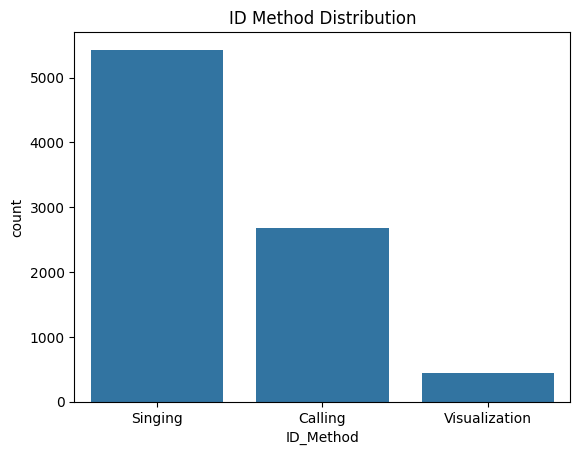

In [17]:
sns.countplot(x='ID_Method', data=combined_df)
plt.title('ID Method Distribution')
plt.show()

In [18]:
combined_df['Common_Name'].nunique()

108

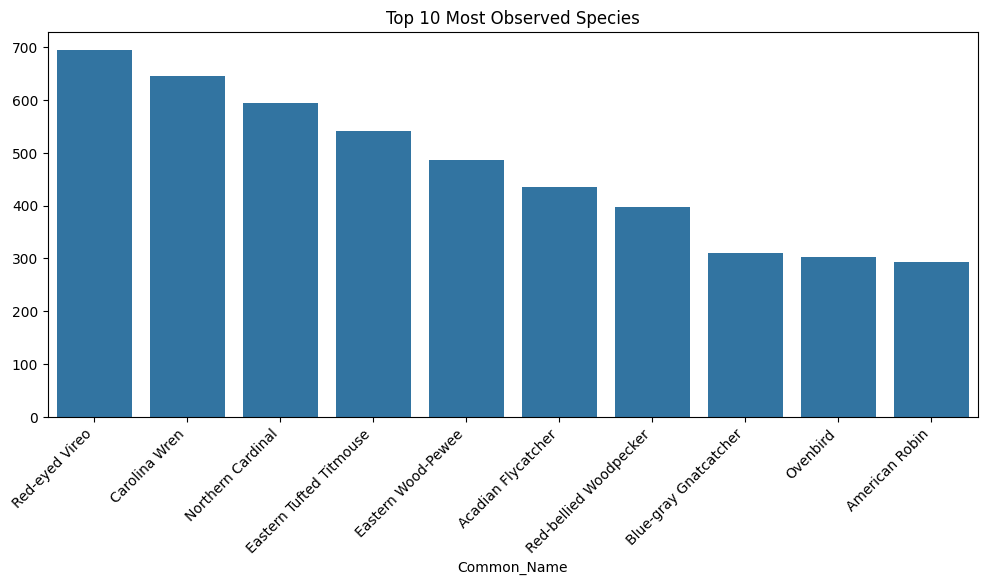

In [19]:
top_species = combined_df['Common_Name'].value_counts().head(10)
plt.figure(figsize=(12, 5))
sns.barplot(x=top_species.index, y=top_species.values)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Observed Species')
plt.show()

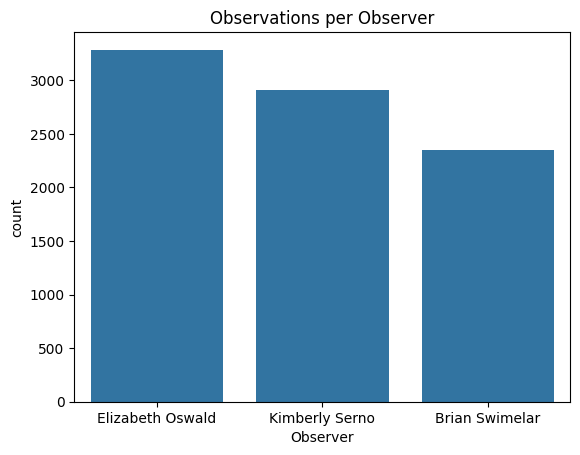

In [20]:
sns.countplot(x='Observer', data=combined_df)
plt.title('Observations per Observer')
plt.show()

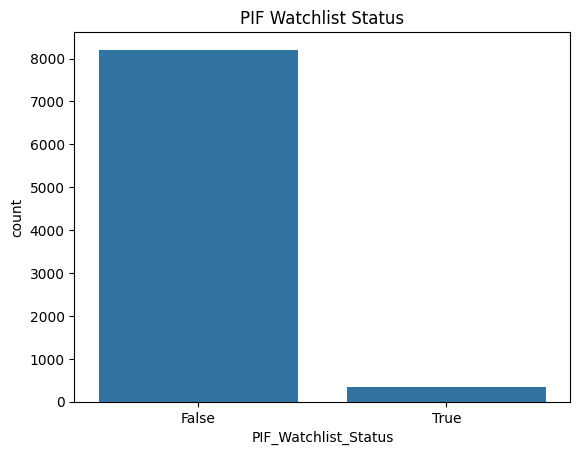

In [21]:
sns.countplot(x='PIF_Watchlist_Status', data=combined_df)
plt.title('PIF Watchlist Status')
plt.show()

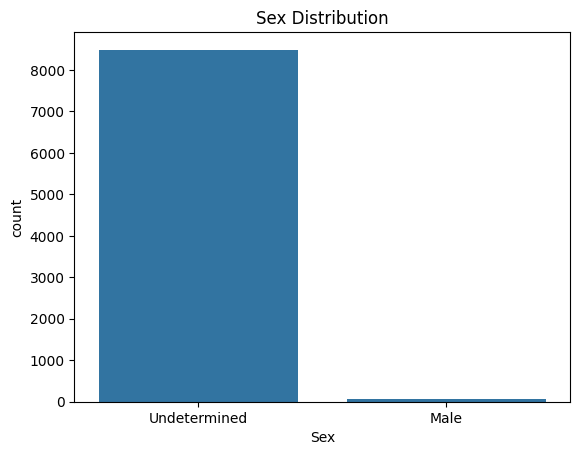

In [22]:
sns.countplot(x='Sex', data=combined_df)
plt.title('Sex Distribution')
plt.show()

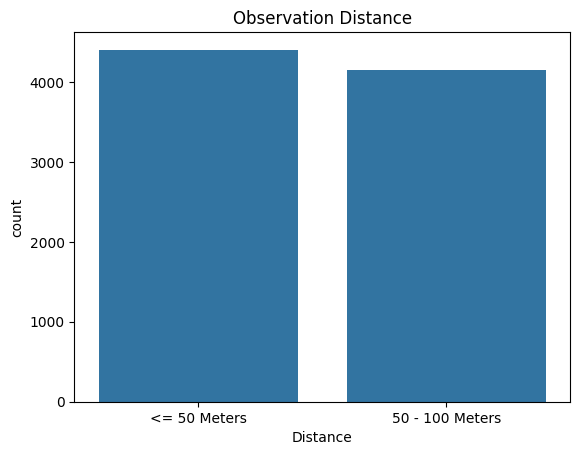

In [23]:
sns.countplot(x='Distance', data=combined_df)
plt.title('Observation Distance')
plt.show()

BIVARIATE ANALYSIS

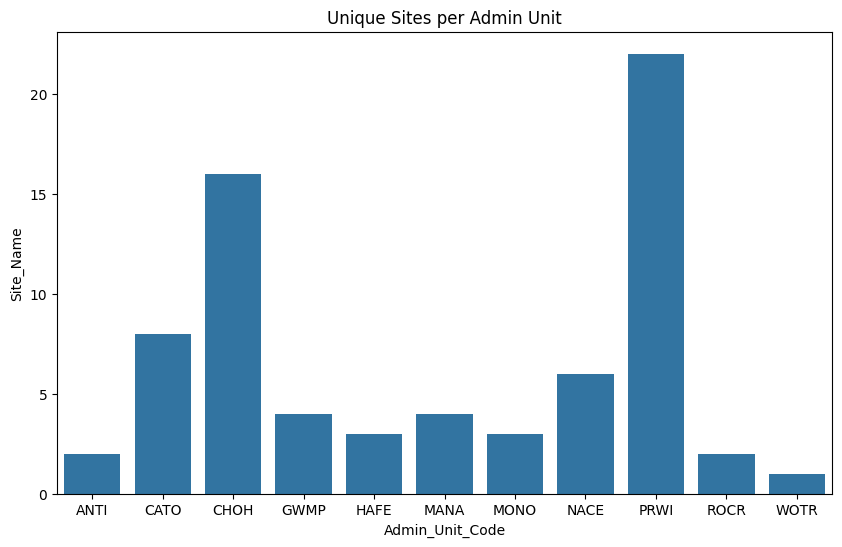

In [24]:
unique_sites = combined_df.groupby('Admin_Unit_Code')['Site_Name'].nunique().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=unique_sites, x='Admin_Unit_Code', y='Site_Name')
plt.title('Unique Sites per Admin Unit')
plt.show()

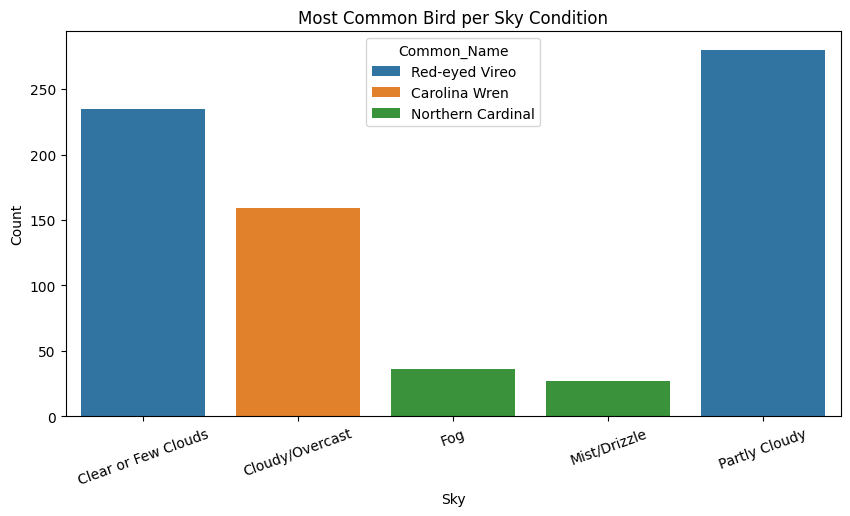

In [25]:
bird_count_by_sky = combined_df.groupby(['Sky', 'Common_Name']).size().reset_index(name='Count')
bird_count_by_sky_max = bird_count_by_sky.loc[bird_count_by_sky.groupby('Sky')['Count'].idxmax()]
plt.figure(figsize=(10, 5))
sns.barplot(data=bird_count_by_sky_max, x='Sky', y='Count', hue='Common_Name')
plt.title('Most Common Bird per Sky Condition')
plt.xticks(rotation=20)
plt.show()

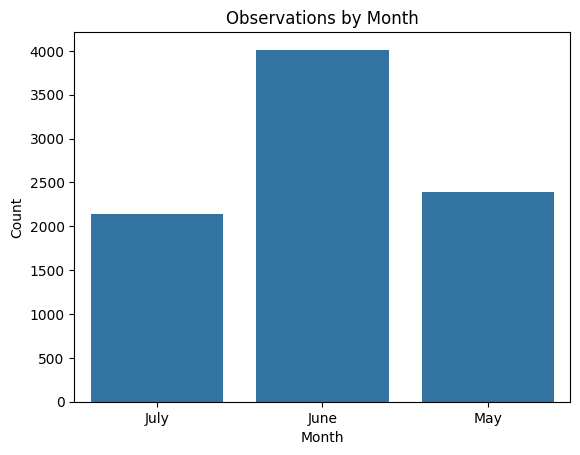

In [26]:
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df['Month'] = combined_df['Date'].dt.month_name()
monthly = combined_df.groupby('Month').size().reset_index(name='Count')
sns.barplot(data=monthly, x='Month', y='Count')
plt.title('Observations by Month')
plt.show()

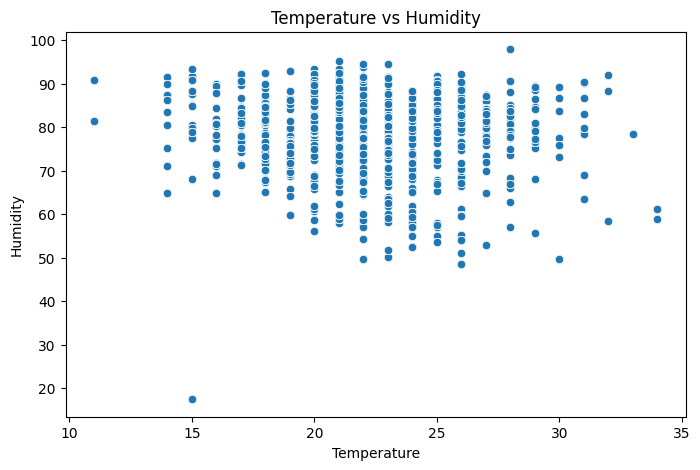

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=combined_df, x='Temperature', y='Humidity')
plt.title('Temperature vs Humidity')
plt.show()

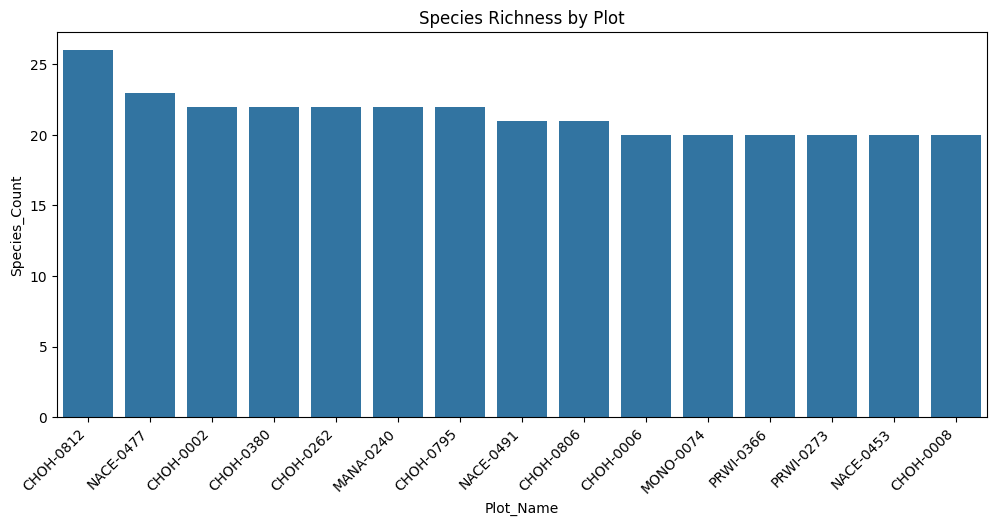

In [28]:
species_per_plot = combined_df.groupby('Plot_Name')['Common_Name'].nunique().reset_index(name='Species_Count')
species_per_plot = species_per_plot.sort_values('Species_Count', ascending=False).head(15)
plt.figure(figsize=(12, 5))
sns.barplot(data=species_per_plot, x='Plot_Name', y='Species_Count')
plt.xticks(rotation=45, ha='right')
plt.title('Species Richness by Plot')
plt.show()